In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================
# Step 1: Load dataset
# =========================
# Make sure your uploaded file name is exactly bank.csv
df = pd.read_csv('/content/bank.csv')

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

# =========================
# Step 2: Handle missing values
# =========================
df = df.dropna().copy()

# =========================
# Step 3: Encode categorical columns
# =========================
label_encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# =========================
# Step 4: Select target column
# =========================
# Last column is assumed target
target_column = df.columns[-1]

X = df.drop(columns=[target_column])
y = df[target_column]

print("\nTarget column:", target_column)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

# =========================
# Step 5: Train-test split
# stratify=y helps keep class balance
# random_state fixed for stable result
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Step 6: Train Random Forest
# Tuned parameters for stronger accuracy
# =========================
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================
# Step 7: Prediction
# =========================
predictions = model.predict(X_test)

# =========================
# Step 8: Accuracy
# =========================
accuracy = accuracy_score(y_test, predictions)
print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

# =========================
# Step 9: Confusion Matrix
# =========================
print("\nConfusion Matrix:\n", confusion_matrix(y_test, predictions))

# =========================
# Step 10: Classification Report
# =========================
print("\nClassification Report:\n", classification_report(y_test, predictions))

# =========================
# Step 11: Feature Importance
# =========================
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(importance_df.head(10))

# =========================
# Step 12: Sample predictions
# =========================
print("\nSample Predictions:", predictions[:10])

Dataset shape: (11162, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579    

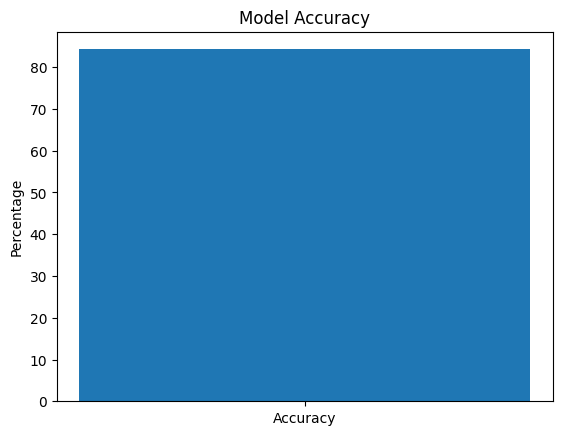

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(['Accuracy'], [accuracy*100])
plt.title('Model Accuracy')
plt.ylabel('Percentage')
plt.show()

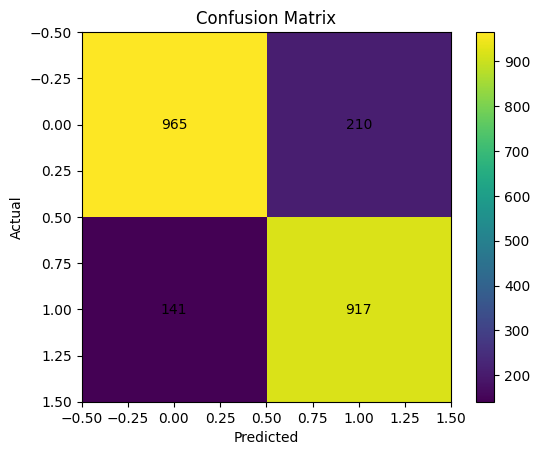

In [ ]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

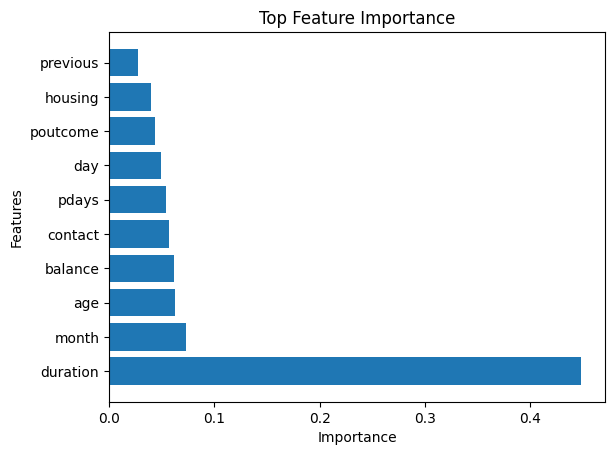

In [ ]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()